In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.load import load_profile, hourly_load
from src.config import HOUSEHOLD_SCALE

fc = pd.read_csv(ROOT / "results" / "forecasts.csv", index_col=0, parse_dates=True)
profile = load_profile(ROOT / "data" / "raw" / "rbee extract by hour and state.csv")
print(len(profile), "half-hour profile rows;", len(fc), "hours to simulate")

1152 half-hour profile rows; 8616 hours to simulate


In [2]:
load = hourly_load(fc.index, profile)          # average household, scale = 1.0
print("missing values:", load.isna().sum())
print("average per day (kWh):", round(load.sum() / (len(load) / 24), 2))
print("total over the period (kWh):", round(load.sum()))
load.resample("MS").sum().round(0)

missing values: 0
average per day (kWh): 16.35
total over the period (kWh): 5870


timestamp
2025-10-01    460.0
2025-11-01    432.0
2025-12-01    480.0
2026-01-01    519.0
2026-02-01    465.0
2026-03-01    485.0
2026-04-01    444.0
2026-05-01    515.0
2026-06-01    558.0
2026-07-01    568.0
2026-08-01    561.0
2026-09-01    383.0
Freq: MS, Name: load_kwh, dtype: float64

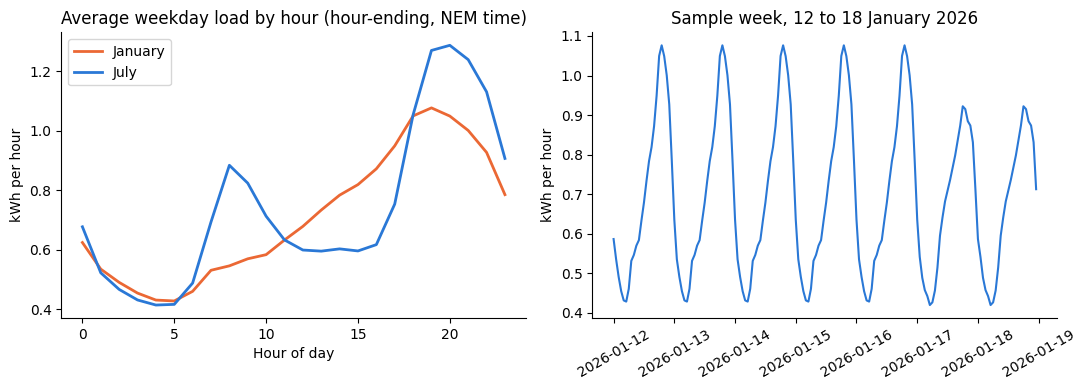

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Average weekday shape, January against July
wk = load[load.index.dayofweek < 5]
for month, colour, label in [(1, "#eb6834", "January"), (7, "#2a78d6", "July")]:
    m = wk[wk.index.month == month]
    axes[0].plot(m.groupby(m.index.hour).mean(), color=colour, label=label, lw=2)
axes[0].set_title("Average weekday load by hour (hour-ending, NEM time)")
axes[0].set_xlabel("Hour of day"); axes[0].set_ylabel("kWh per hour"); axes[0].legend()

# One sample week
week = load["2026-01-12":"2026-01-18"]
axes[1].plot(week.index, week.values, color="#2a78d6")
axes[1].set_title("Sample week, 12 to 18 January 2026")
axes[1].set_ylabel("kWh per hour")
axes[1].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ROOT / "results" / "fig_household_load.png", dpi=150)
plt.show()

In [4]:
out = load.to_frame()
out.index.name = "timestamp"
out.to_csv(ROOT / "data" / "processed" / "household_load_hourly.csv")
print(out.shape)

(8616, 1)
